In [14]:
# Импорт необходимых библиотек
import zipfile
import json
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

# Настройка стиля графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


In [15]:
# Путь к архиву с датасетами
DATASET_PATH = "DAMM_mouse_detection/tracking_datasets.zip"
EXTRACT_PATH = "tracking_datasets_extracted"

# Разархивирование датасета (если еще не разархивирован)
if not os.path.exists(EXTRACT_PATH):
    print("Разархивирование датасета...")
    with zipfile.ZipFile(DATASET_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)
    print(f"Датасет разархивирован в {EXTRACT_PATH}")
else:
    print(f"Датасет уже находится в {EXTRACT_PATH}")


Датасет уже находится в tracking_datasets_extracted


In [16]:
# Функция для извлечения метаданных видео из JSON и видео файла
def extract_video_metadata(json_path, video_path):
    """
    Извлекает метаданные о видео из JSON файла и видео файла
    
    Parameters:
    -----------
    json_path : str
        Путь к файлу metadata.json
    video_path : str
        Путь к видео файлу
        
    Returns:
    --------
    dict : Словарь с метаданными видео
    """
    # Загрузка JSON файла
    with open(json_path, 'r') as f:
        metadata = json.load(f)
    
    # Извлечение информации из JSON
    video_name = metadata.get('video_name', 'unknown')
    annotations = metadata.get('annotations', [])
    num_annotated_frames = len(annotations)
    
    # Получение frame_id из всех кадров для определения диапазона
    frame_ids = [ann['frame_id'] for ann in annotations] if annotations else []
    max_frame_id = max(frame_ids) if frame_ids else 0
    
    # Получение информации о видео из файла
    video_info = {}
    if os.path.exists(video_path):
        cap = cv2.VideoCapture(video_path)
        if cap.isOpened():
            # Получение FPS
            fps = cap.get(cv2.CAP_PROP_FPS)
            # Получение количества кадров
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            # Получение размеров кадра
            width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
            height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
            # Вычисление длительности в секундах
            duration_seconds = total_frames / fps if fps > 0 else 0
            
            video_info = {
                'fps': fps,
                'total_frames': total_frames,
                'width': width,
                'height': height,
                'duration_seconds': duration_seconds
            }
            cap.release()
    
    # Объединение информации
    result = {
        'video_name': video_name,
        'num_annotated_frames': num_annotated_frames,
        'max_frame_id': max_frame_id,
        **video_info
    }
    
    return result


In [17]:
# Поиск всех видео и соответствующих JSON файлов
base_path = Path(EXTRACT_PATH) / "tracking_datasets"
video_data = []

# Поиск в папках single_animal_tracking и multi_animal_tracking
for tracking_type in ['single_animal_tracking', 'multi_animal_tracking']:
    tracking_path = base_path / tracking_type
    if tracking_path.exists():
        # Итерация по всем папкам с видео
        for video_folder in tracking_path.iterdir():
            if video_folder.is_dir():
                # Поиск JSON и видео файлов
                json_file = video_folder / "metadata.json"
                # Поиск видео файла (может быть .mp4)
                video_files = list(video_folder.glob("*.mp4"))
                
                if json_file.exists() and video_files:
                    video_file = video_files[0]  # Берем первый найденный видео файл
                    try:
                        metadata = extract_video_metadata(str(json_file), str(video_file))
                        metadata['tracking_type'] = tracking_type
                        metadata['folder_name'] = video_folder.name
                        video_data.append(metadata)
                    except Exception as e:
                        print(f"Ошибка при обработке {video_folder.name}: {e}")

print(f"Найдено видео: {len(video_data)}")


Найдено видео: 12


In [18]:
# Создание DataFrame с метаданными
df = pd.DataFrame(video_data)

# Переименование колонок для лучшей читаемости
column_mapping = {
    'video_name': 'Video Name',
    'tracking_type': 'Tracking Type',
    'folder_name': 'Folder Name',
    'fps': 'Fps',
    'total_frames': 'Total Frames',
    'width': 'Width',
    'height': 'Height',
    'duration_seconds': 'Duration Seconds',
    'num_annotated_frames': 'Num Annotated Frames',
    'max_frame_id': 'Max Frame Id'
}

# Переименование колонок
df.rename(columns=column_mapping, inplace=True)

# Создание короткого имени для каждого видео (имя файла без пути)
df['Short Name'] = df['Video Name'].apply(lambda x: x.split('/')[-1].replace('.mp4', ''))

# Сортировка по имени видео для удобства
df = df.sort_values('Short Name').reset_index(drop=True)

# Вывод основной информации о датасете
print("=" * 60)
print("ОСНОВНАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ")
print("=" * 60)
print(f"\nОбщее количество видео: {len(df)}")


ОСНОВНАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ

Общее количество видео: 12


In [19]:
# Вывод детальной информации по каждому видео
print("\n" + "=" * 60)
print("ДЕТАЛЬНАЯ ИНФОРМАЦИЯ ПО ВСЕМ ВИДЕО")
print("=" * 60)

# Форматирование вывода для лучшей читаемости
display_columns = ['Video Name', 'Tracking Type', 'Fps', 'Total Frames', 
                   'Width', 'Height', 'Duration Seconds', 'Num Annotated Frames']
display_df = df[display_columns].copy()

# Округление числовых значений
display_df['Fps'] = display_df['Fps'].round(2)
display_df['Duration Seconds'] = display_df['Duration Seconds'].round(2)

print(display_df.to_string(index=False))



ДЕТАЛЬНАЯ ИНФОРМАЦИЯ ПО ВСЕМ ВИДЕО
                                                                         Video Name          Tracking Type   Fps  Total Frames  Width  Height  Duration Seconds  Num Annotated Frames
                                                   single_animal_tracking/epm_1.mp4 single_animal_tracking 25.00          3942   1280     960            157.69                  2410
                         multi_animal_tracking/golden_mouse_home_cage_social_72.mp4  multi_animal_tracking 30.00          1470   1000    1544             49.00                  1470
single_animal_tracking/golden_mouse_open_field_social_familiarity_cd1_absent_01.mp4 single_animal_tracking 30.00          1387   1500    1350             46.23                  1387
        multi_animal_tracking/golden_mouse_operant_chamber_social_self_admin_09.mp4  multi_animal_tracking 30.00          1565    800     600             52.17                   437
           single_animal_tracking/mcdannald_rat_operan

C:\Users\foksm\AppData\Local\Temp\ipykernel_17708\470060799.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Short Name', y='Fps', palette='viridis')


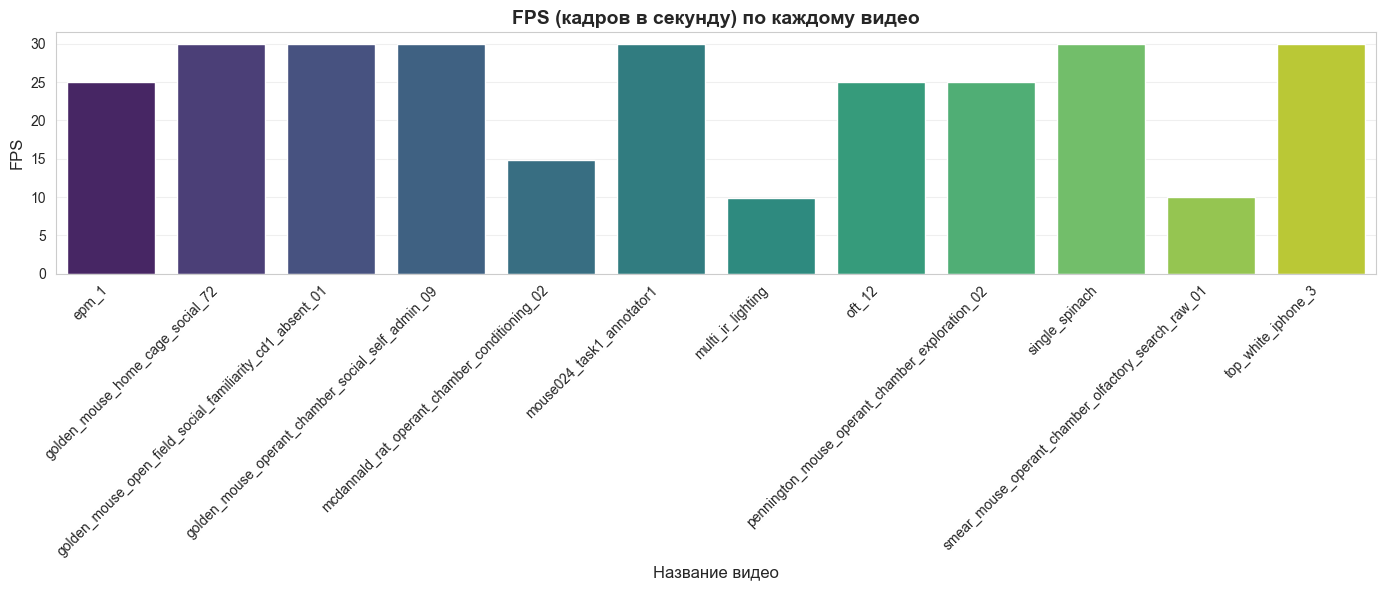


FPS ПО КАЖДОМУ ВИДЕО
                                              Short Name   Fps
                                                   epm_1 25.00
                        golden_mouse_home_cage_social_72 30.00
golden_mouse_open_field_social_familiarity_cd1_absent_01 30.00
       golden_mouse_operant_chamber_social_self_admin_09 30.00
           mcdannald_rat_operant_chamber_conditioning_02 14.81
                               mouse024_task1_annotator1 30.00
                                       multi_ir_lighting  9.91
                                                  oft_12 25.00
         pennington_mouse_operant_chamber_exploration_02 25.00
                                          single_spinach 30.00
     smear_mouse_operant_chamber_olfactory_search_raw_01 10.00
                                      top_white_iphone_3 29.97


In [20]:
# Визуализация FPS для каждого видео
plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='Short Name', y='Fps', palette='viridis')
plt.title('FPS (кадров в секунду) по каждому видео', fontsize=14, fontweight='bold')
plt.xlabel('Название видео', fontsize=12)
plt.ylabel('FPS', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод FPS для каждого видео
print("\n" + "=" * 60)
print("FPS ПО КАЖДОМУ ВИДЕО")
print("=" * 60)
fps_df = df[['Short Name', 'Fps']].copy()
fps_df['Fps'] = fps_df['Fps'].round(2)
print(fps_df.to_string(index=False))


C:\Users\foksm\AppData\Local\Temp\ipykernel_17708\4206661150.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Short Name', y='Duration Seconds', palette='viridis')


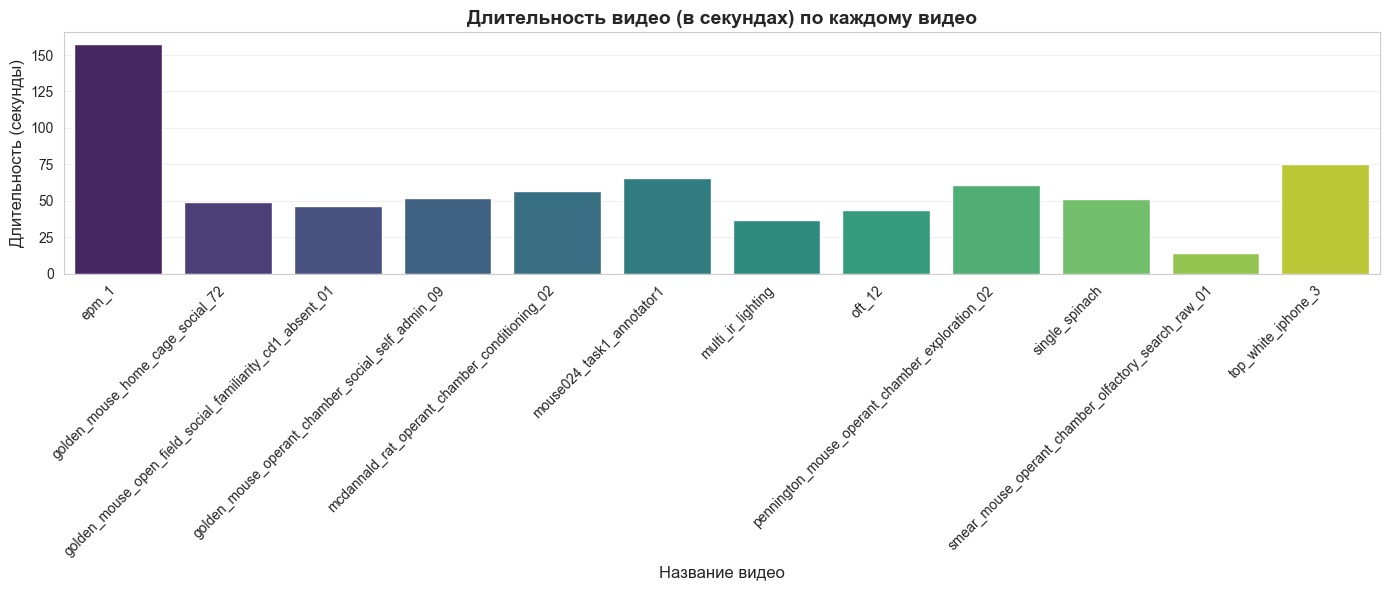


ДЛИТЕЛЬНОСТЬ ПО КАЖДОМУ ВИДЕО
                                              Short Name  Duration Seconds
                                                   epm_1            157.69
                        golden_mouse_home_cage_social_72             49.00
golden_mouse_open_field_social_familiarity_cd1_absent_01             46.23
       golden_mouse_operant_chamber_social_self_admin_09             52.17
           mcdannald_rat_operant_chamber_conditioning_02             56.73
                               mouse024_task1_annotator1             65.50
                                       multi_ir_lighting             36.82
                                                  oft_12             43.36
         pennington_mouse_operant_chamber_exploration_02             60.56
                                          single_spinach             51.03
     smear_mouse_operant_chamber_olfactory_search_raw_01             14.50
                                      top_white_iphone_3             

In [21]:
# Визуализация длительности для каждого видео
plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='Short Name', y='Duration Seconds', palette='viridis')
plt.title('Длительность видео (в секундах) по каждому видео', fontsize=14, fontweight='bold')
plt.xlabel('Название видео', fontsize=12)
plt.ylabel('Длительность (секунды)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод длительности для каждого видео
print("\n" + "=" * 60)
print("ДЛИТЕЛЬНОСТЬ ПО КАЖДОМУ ВИДЕО")
print("=" * 60)
duration_df = df[['Short Name', 'Duration Seconds']].copy()
duration_df['Duration Seconds'] = duration_df['Duration Seconds'].round(2)
print(duration_df.to_string(index=False))


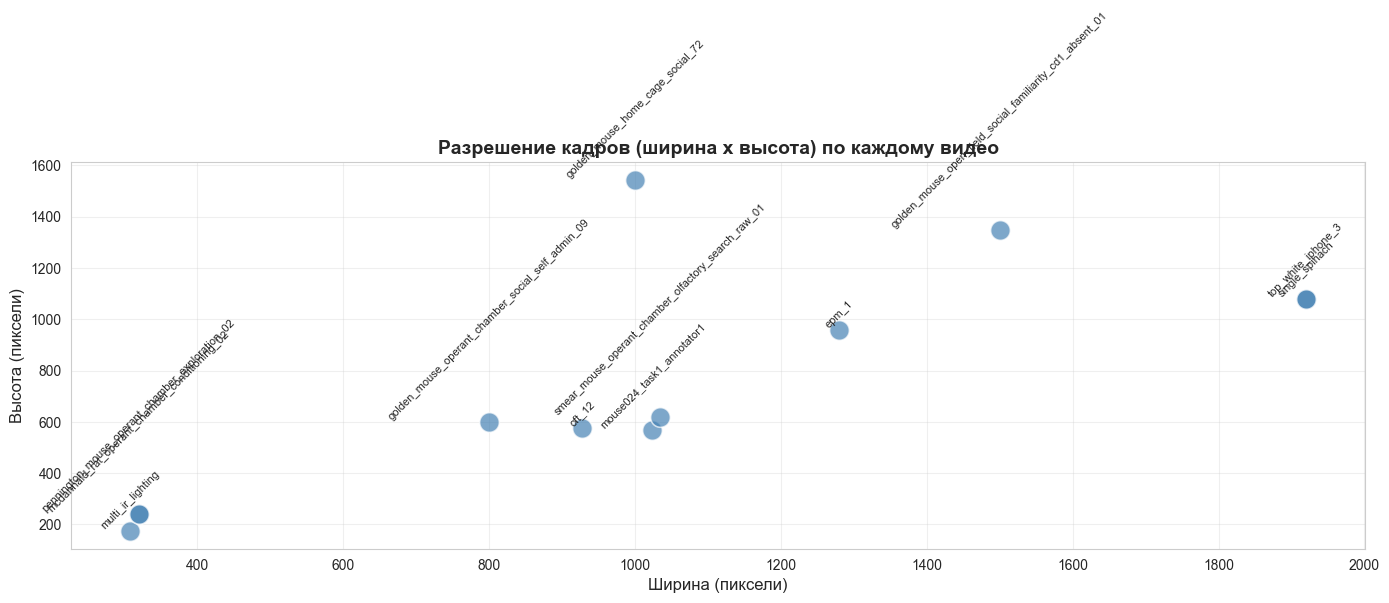


РАЗРЕШЕНИЕ ПО КАЖДОМУ ВИДЕО
                                              Short Name  Width  Height Resolution
                                                   epm_1   1280     960   1280x960
                        golden_mouse_home_cage_social_72   1000    1544  1000x1544
golden_mouse_open_field_social_familiarity_cd1_absent_01   1500    1350  1500x1350
       golden_mouse_operant_chamber_social_self_admin_09    800     600    800x600
           mcdannald_rat_operant_chamber_conditioning_02    320     240    320x240
                               mouse024_task1_annotator1   1024     570   1024x570
                                       multi_ir_lighting    308     174    308x174
                                                  oft_12    928     576    928x576
         pennington_mouse_operant_chamber_exploration_02    320     240    320x240
                                          single_spinach   1920    1080  1920x1080
     smear_mouse_operant_chamber_olfactory_search_raw_01  

In [22]:
# Визуализация размеров кадров (разрешение) для каждого видео
df['Resolution'] = df['Width'].astype(str) + 'x' + df['Height'].astype(str)

plt.figure(figsize=(14, 6))
# График разрешений с подписями видео
sns.scatterplot(data=df, x='Width', y='Height', s=200, alpha=0.7, color='steelblue')
# Добавление подписей для каждого видео
for idx, row in df.iterrows():
    plt.text(row['Width'], row['Height'], row['Short Name'], 
             fontsize=8, ha='center', va='bottom', rotation=45)
plt.title('Разрешение кадров (ширина x высота) по каждому видео', fontsize=14, fontweight='bold')
plt.xlabel('Ширина (пиксели)', fontsize=12)
plt.ylabel('Высота (пиксели)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод разрешений для каждого видео
print("\n" + "=" * 60)
print("РАЗРЕШЕНИЕ ПО КАЖДОМУ ВИДЕО")
print("=" * 60)
resolution_df = df[['Short Name', 'Width', 'Height', 'Resolution']].copy()
print(resolution_df.to_string(index=False))


C:\Users\foksm\AppData\Local\Temp\ipykernel_17708\2603632546.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Short Name', y='Annotation Coverage', palette='viridis')


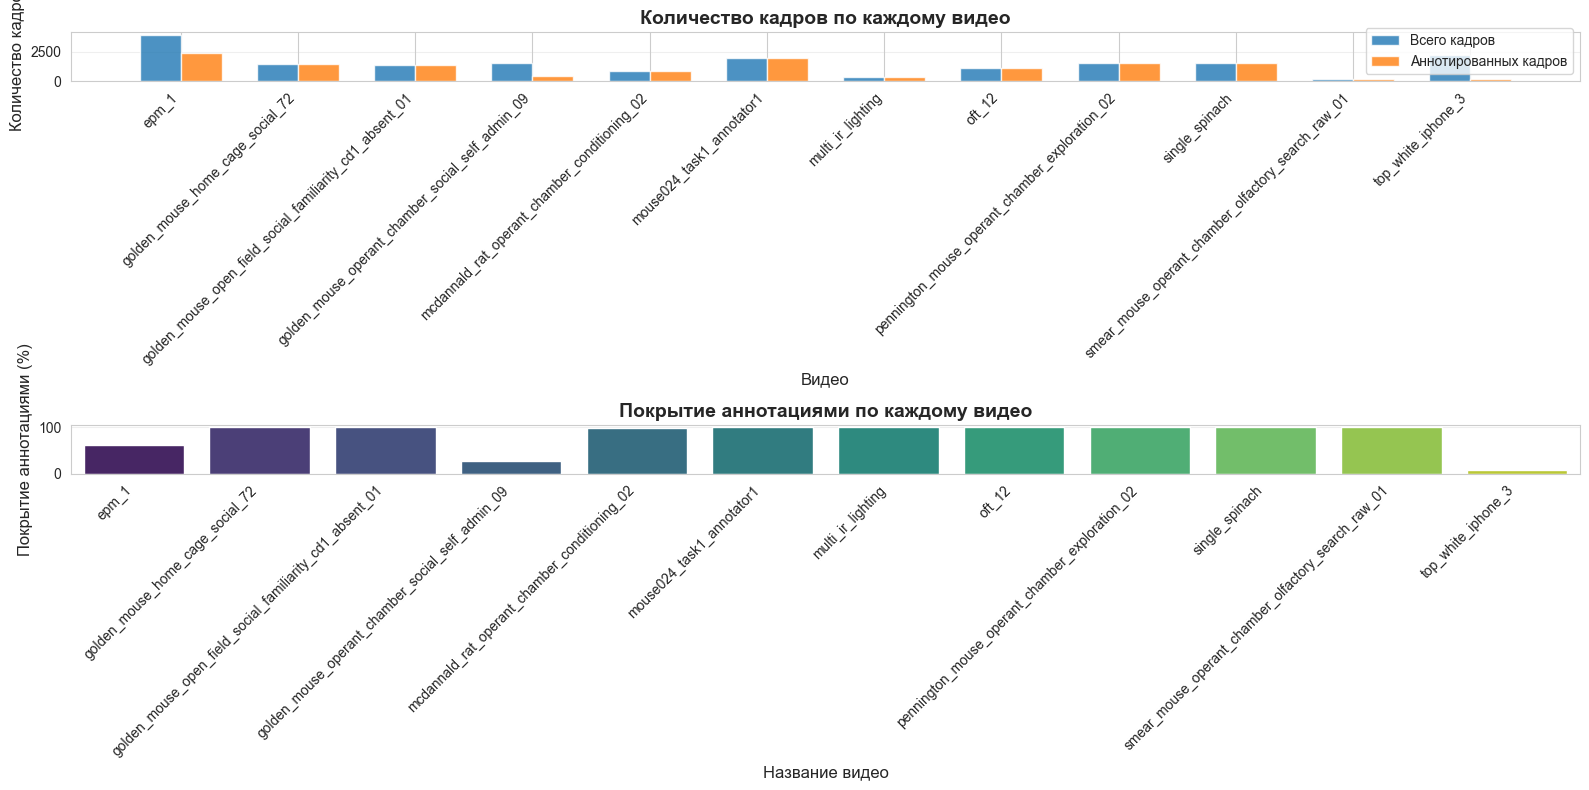


ИНФОРМАЦИЯ О КАДРАХ ПО КАЖДОМУ ВИДЕО
                                              Short Name  Total Frames  Num Annotated Frames  Annotation Coverage
                                                   epm_1          3942                  2410                61.14
                        golden_mouse_home_cage_social_72          1470                  1470               100.00
golden_mouse_open_field_social_familiarity_cd1_absent_01          1387                  1387               100.00
       golden_mouse_operant_chamber_social_self_admin_09          1565                   437                27.92
           mcdannald_rat_operant_chamber_conditioning_02           840                   828                98.57
                               mouse024_task1_annotator1          1965                  1965               100.00
                                       multi_ir_lighting           365                   365               100.00
                                                  

In [23]:
# Вычисление покрытия аннотациями
df['Annotation Coverage'] = (df['Num Annotated Frames'] / df['Total Frames'] * 100).round(2)

# Визуализация количества кадров для каждого видео
plt.figure(figsize=(16, 8))

plt.subplot(2, 1, 1)
x_pos = np.arange(len(df))
width = 0.35
plt.bar(x_pos - width/2, df['Total Frames'], width, label='Всего кадров', alpha=0.8)
plt.bar(x_pos + width/2, df['Num Annotated Frames'], width, label='Аннотированных кадров', alpha=0.8)
plt.xlabel('Видео', fontsize=12)
plt.ylabel('Количество кадров', fontsize=12)
plt.title('Количество кадров по каждому видео', fontsize=14, fontweight='bold')
plt.xticks(x_pos, df['Short Name'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(2, 1, 2)
sns.barplot(data=df, x='Short Name', y='Annotation Coverage', palette='viridis')
plt.xlabel('Название видео', fontsize=12)
plt.ylabel('Покрытие аннотациями (%)', fontsize=12)
plt.title('Покрытие аннотациями по каждому видео', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод информации о кадрах для каждого видео
print("\n" + "=" * 60)
print("ИНФОРМАЦИЯ О КАДРАХ ПО КАЖДОМУ ВИДЕО")
print("=" * 60)
frames_df = df[['Short Name', 'Total Frames', 'Num Annotated Frames', 'Annotation Coverage']].copy()
frames_df['Annotation Coverage'] = frames_df['Annotation Coverage'].round(2)
print(frames_df.to_string(index=False))


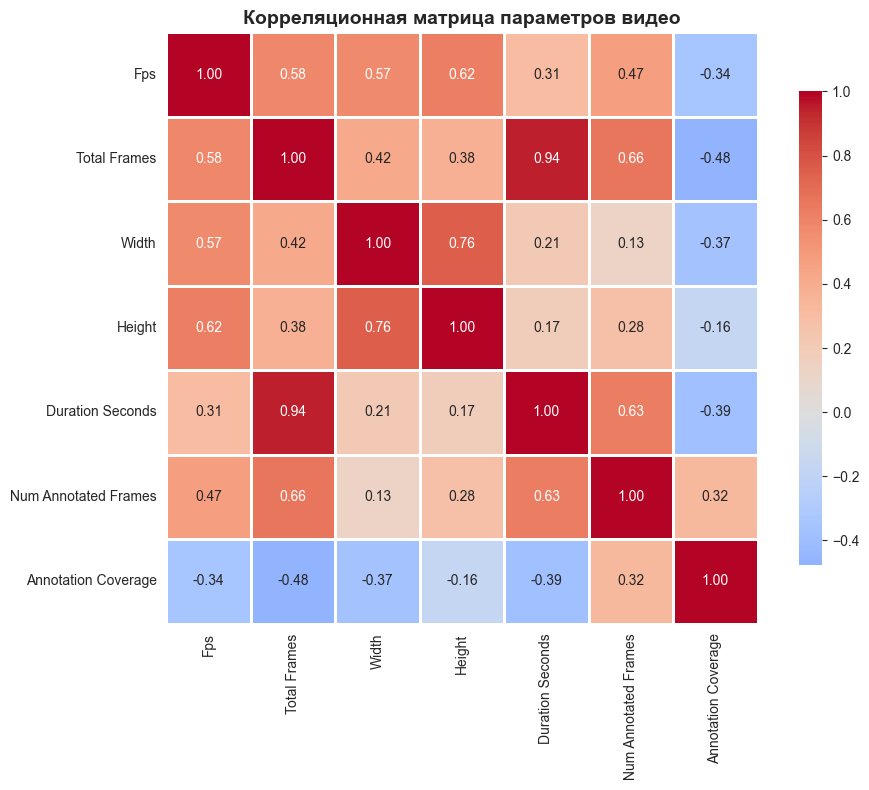

In [24]:
# Корреляционная матрица числовых параметров
numeric_columns = ['Fps', 'Total Frames', 'Width', 'Height', 'Duration Seconds', 
                   'Num Annotated Frames', 'Annotation Coverage']
# Проверка наличия всех колонок
available_columns = [col for col in numeric_columns if col in df.columns]
correlation_matrix = df[available_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица параметров видео', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [25]:
# Полная таблица со всеми параметрами для каждого видео
print("=" * 60)
print("ПОЛНАЯ СТАТИСТИКА ПО КАЖДОМУ ВИДЕО")
print("=" * 60)

# Создание итоговой таблицы с округлением
summary_df = df[['Short Name', 'Video Name', 'Tracking Type', 'Fps', 'Total Frames', 
                 'Width', 'Height', 'Duration Seconds', 'Num Annotated Frames', 
                 'Annotation Coverage']].copy()

# Округление числовых значений
summary_df['Fps'] = summary_df['Fps'].round(2)
summary_df['Duration Seconds'] = summary_df['Duration Seconds'].round(2)
summary_df['Annotation Coverage'] = summary_df['Annotation Coverage'].round(2)

# Вывод полной таблицы
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)
print(summary_df.to_string(index=False))

print("\n" + "=" * 60)
print("КРАТКАЯ СВОДКА")
print("=" * 60)
print(f"\nОбщее количество видео: {len(df)}")
print(f"  - Single animal tracking: {len(df[df['Tracking Type'] == 'single_animal_tracking'])}")
print(f"  - Multi animal tracking: {len(df[df['Tracking Type'] == 'multi_animal_tracking'])}")


ПОЛНАЯ СТАТИСТИКА ПО КАЖДОМУ ВИДЕО
                                              Short Name                                                                          Video Name          Tracking Type   Fps  Total Frames  Width  Height  Duration Seconds  Num Annotated Frames  Annotation Coverage
                                                   epm_1                                                    single_animal_tracking/epm_1.mp4 single_animal_tracking 25.00          3942   1280     960            157.69                  2410                61.14
                        golden_mouse_home_cage_social_72                          multi_animal_tracking/golden_mouse_home_cage_social_72.mp4  multi_animal_tracking 30.00          1470   1000    1544             49.00                  1470               100.00
golden_mouse_open_field_social_familiarity_cd1_absent_01 single_animal_tracking/golden_mouse_open_field_social_familiarity_cd1_absent_01.mp4 single_animal_tracking 30.00          1387  